# AG-HYPOPT · Trial 02

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Campaign state at trial_02. Registry has one trial: trial_01 = target rule, h_f 5.349, h_s 7.652 ->
objective 0.0837 ± 0.0211, gamma finite on all 8 cells, 0 diverged. That clears the success bar
(~0.086) but sits just above exp6's headline 0.0803, which was reached with the same (target) rule at
h_f 4.0, h_s 3.675. So pushing the target rule's coefficients up from 4/3.7 to 5.35/7.65 did not
improve things, which is the first sign of a turnover just above exp6's winning point. The two new
rules, `sim` and `power`, are still untested. Only trial_01 exists as evidence; this is trial 2 of 30.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_02'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (1/5 trials)
ID |     ei | params
 1 |      - | {"bandwidth_rule": "power", "h_f_scale": 4.283402577555356, "h_s_scale": 9.956483146537083}
 2 |      - | {"bandwidth_rule": "target", "h_f_scale": 2.011075363486066, "h_s_scale": 7.6011057856221935}
 3 |      - | {"bandwidth_rule": "power", "h_f_scale": 3.0669118070326378, "h_s_scale": 1.60661290066375}
 4 |      - | {"bandwidth_rule": "power", "h_f_scale": 4.024663046966419, "h_s_scale": 8.231763163631518}
 5 |      - | {"bandwidth_rule": "target", "h_f_scale": 2.6506848963586975, "h_s_scale": 5.758938698852659}
 6 |      - | {"bandwidth_rule": "sim", "h_f_scale": 8.362270284319724, "h_s_scale": 5.650631405971406}
 7 |      - | {"bandwidth_rule": "target", "h_f_scale": 11.641795477430444, "h_s_scale": 8.51371304540588}
 8 |      - | {"bandwidth_rule": "sim", "h_f_scale": 5.307873163880288, "h_s_scale": 3.0597782669210787}
 9 |      - | {"bandwidth_rule": "target", "h_f_scale": 6.621725709265347, "h_s_scale": 10.80330350

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Only one prior trial (trial_01: target, 5.349/7.652 -> 0.0837), so evidence is thin. The one firm
fact is that the `target` rule did not improve when pushed above exp6's optimum (h_f 4.0); the rule
family itself is what exp7 is meant to answer, and `sim` and `power` have not been touched yet. The
most informative next move is therefore to test a new rule at a bandwidth scale comparable to the
best-known target point, so the comparison isolates the RULE rather than the coefficient size.

Among the proposals, the `sim` candidates are #6 (8.36/5.65), #8 (5.31/3.06) and #10 (9.53/4.50).
Candidate #8 sits closest to the best-known region (h_f 5.31 ~ trial_01's 5.35, h_s 3.06 ~ exp6's
3.675) while switching only the rule, so its result reads directly against trial_01 / exp6. The `sim`
rule is also the mechanistically distinct one (sim-adaptive bandwidth that shrinks as mu grows), so it
probes the mismatch the campaign is built around. The near-cap candidates (#6, #10) and the lower-
bandwidth `power` options (#1, #3, #4) can follow once a rule effect is visible.

I choose candidate 8 (sim, h_f_scale 5.308, h_s_scale 3.060).


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 8            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'bandwidth_rule': 'sim', 'h_f_scale': 5.307873163880288, 'h_s_scale': 3.0597782669210787}
Running  1nW Trans05 ... 

μ 9.39 -> 8.82 | γ 8.5 -> 2.62 | NLL 8.03


Running  1nW Trans20 ... 

μ 17.32 -> 15.82 | γ 8.5 -> 3.20 | NLL 0.87


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 56.82 | γ 14.1 -> 12.58 | NLL 1.26


Running 3nW Trans100 ... 

μ 175.71 -> 91.36 | γ 14.1 -> 13.08 | NLL 0.18



Total: 7.2 min


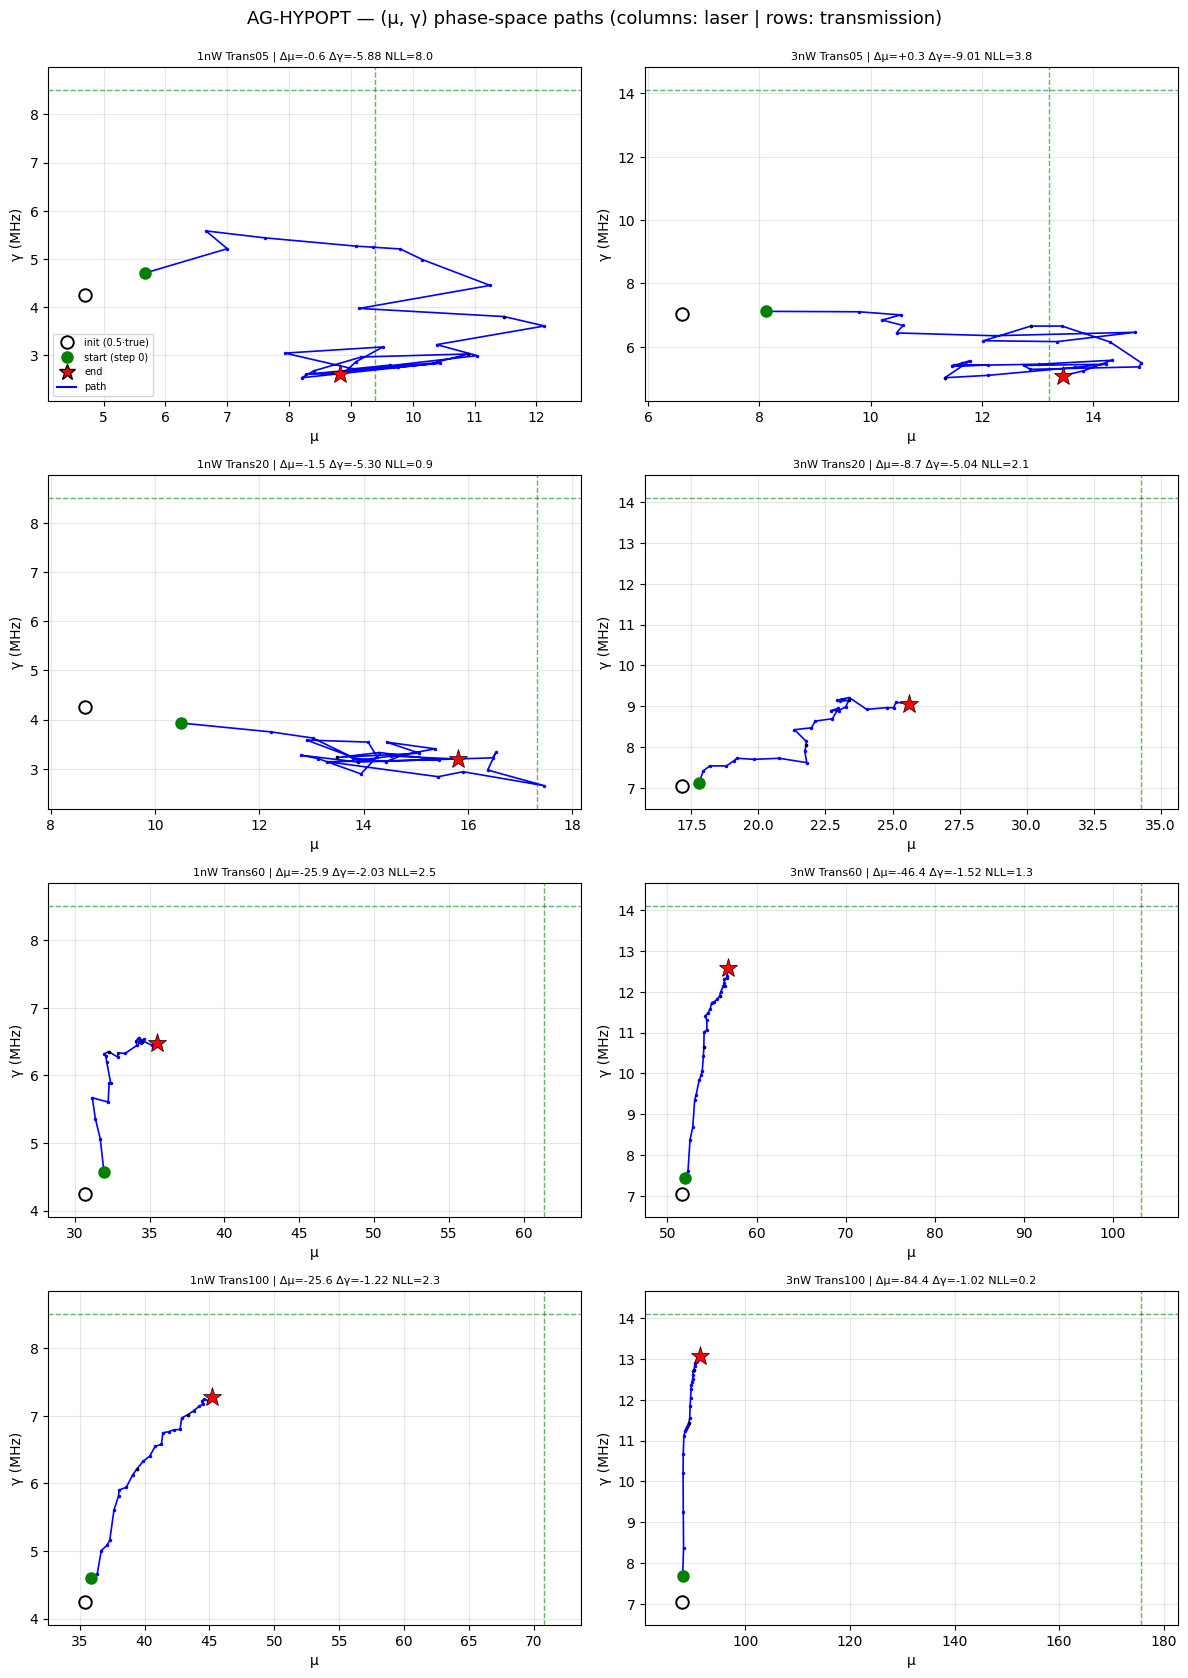

trial finished in 7.2 min
objective = 0.1249 ± 0.0398
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    8.82    -6.1 |     8.50    2.62   -69.2
1nW Trans20       17.32   15.82    -8.7 |     8.50    3.20   -62.4
1nW Trans60       61.37   35.48   -42.2 |     8.50    6.47   -23.9
1nW Trans100       70.82   45.24   -36.1 |     8.50    7.28   -14.4
3nW Trans05       13.20   13.46    +1.9 |    14.10    5.09   -63.9
3nW Trans20       34.28   25.61   -25.3 |    14.10    9.06   -35.8
3nW Trans60      103.20   56.82   -44.9 |    14.10   12.58   -10.8
3nW Trans100      175.71   91.36   -48.0 |    14.10   13.08    -7.2

weighted objective (T-graded, cap=1.0) = 0.1249 | diverged cells: 0
μ: RMSE 36.520 (rel 31.9%, bias -24.088) | γ: RMSE 4.721 (rel 43.3%, bias -3.878)


TypeError: unsupported operand type(s) for -: 'str' and 'str'

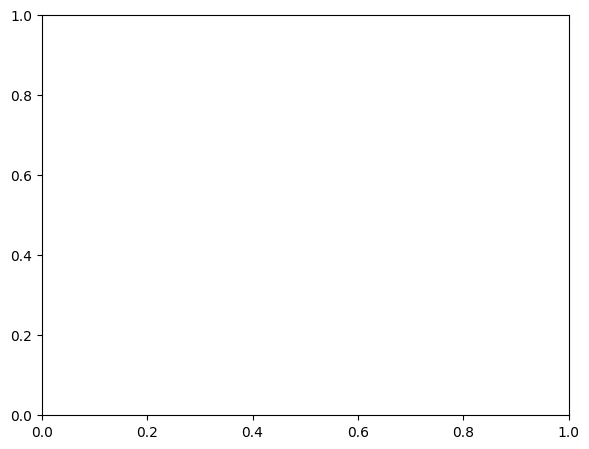

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Objective = 0.1249 ± 0.0398, gamma finite on all 8 cells, diverged cells: 0. Config: bandwidth_rule =
sim, h_f_scale = 5.308, h_s_scale = 3.060 - a new rule at a bandwidth scale comparable to the best
known target point.

This is clearly worse than trial_01 (0.0837). mu rel-RMSE 31.9 % (bias -24.1) is essentially the
same as trial_01's 32.9 %, but gamma rel-RMSE jumps to 43.3 % (bias -3.88) versus trial_01's 27.3 %,
and that is what drives the objective up. gamma is far too low in exactly the low-count cells:
1nW Trans05 2.62 vs 8.50 (-69.2 %), 1nW Trans20 3.20 vs 8.50 (-62.4 %), 3nW Trans05 5.09 vs 14.10
(-63.9 %), 3nW Trans20 9.06 vs 14.10 (-35.8 %); the high-T cells are also degraded relative to trial_01
(3nW Trans100 -7.2 % vs -3.7 %, 1nW Trans60 -23.9 % vs -15.4 %). The per-cell NLLs (0.87-8.03) are an
order of magnitude above trial_01's (0.10-0.43), i.e. the likelihood itself is a much poorer match,
not just the test metric. mu remains underestimated in the same pattern as trial_01.

So at this bandwidth scale the `sim` rule is markedly worse than `target`, via a gamma-collapse
mechanism concentrated in the low-count cells - consistent with the sim-adaptive width shrinking and
making the kernel knife-edge/spiky exactly where the gamma gradient is already noise-limited.

Execution note: same trailing `plot_parallel` diagnostic failure as trial_01 (`TypeError:`
unsupported operand type(s) for -: 'str' and 'str'` at ag_hypopt.py:1216, from normalising the string
`bandwidth_rule` axis). It fires after the objective is computed and printed, so the trial stands; the
diagnostic figure simply does not render. No rerun.

**Summary:** Trial 2 (sim rule, h_f 5.308, h_s 3.060) scores objective 0.1249 ± 0.0398 with gamma finite and no divergence, far worse than trial_01 (0.0837) because gamma collapses in all four low-count cells.
**Key insight:** The `sim` bandwidth rule is decisively inferior to `target` at comparable bandwidth: it drives gamma to 31-40 % of truth on the Trans05/Trans20 cells and lifts the objective from 0.0837 to 0.1249.

Notes for Anuar (optional, not acted on): the `plot_parallel` label bug is now confirmed to fire on
every trial; it only affects the campaign's diagnostic figure and remains outside scope.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 2 (sim rule, h_f 5.308, h_s 3.060) scores objective 0.1249 ± 0.0398 with gamma finite and no divergence, far worse than trial_01 (0.0837) because gamma collapses in all four low-count cells."      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The `sim` bandwidth rule is decisively inferior to `target` at comparable bandwidth: it drives gamma to 31-40 % of truth on the Trans05/Trans20 cells and lifts the objective from 0.0837 to 0.1249."  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_02 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_03.ipynb. Open it and follow its cells from the top.
